# FINAL PROJECT: Our 10-Model Sentiment Stacking Ensemble
## Goal: Solving the "Domain Shift" and Reaching 89%+ Accuracy

**Our Team's Integrated Effort:**
- **Ivy:** Fast SVM (LinearSVC) & Bi-LSTM
- **Larry:** Naive Bayes & TextCNN (15k Bigram Features)
- **Ritah:** Logistic Regression & LSTM
- **Julianah:** 300-Tree Random Forest & Bi-GRU
- **David:** Optimized DistilBERT (The heavyweight 88% anchor!)
- **Ensemble:** XGBoost Manager (Tuned for high generalization)

---

## PART 1: SETUP & LIBRARIES
In this first section, we are importing all the tools we need to build our 10 models. We are bringing in standard libraries like Pandas for data, Scikit-Learn for classical machine learning, and TensorFlow/PyTorch for our deep learning models. 

**What the code below is doing:**
It loads the 'engines' for our models and sets up a **Critical GPU Fix**. Since we are mixing two different deep learning engines (TensorFlow and PyTorch), we need to make sure they share the GPU nicely so David's BERT model has enough room to run without crashing!

In [1]:
import os, re, string, random, zipfile, urllib.request, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse
import shap
from lime.lime_tabular import LimeTabularExplainer
from matplotlib.patches import FancyBboxPatch
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Embedding, LSTM, GRU, Dense, Dropout, SpatialDropout1D, Bidirectional,
    Input, Concatenate, GlobalAveragePooling1D, GlobalMaxPooling1D, Conv1D
)
from tensorflow.keras.callbacks import EarlyStopping

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import xgboost as xgb

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.set_logical_device_configuration(
            gpus[0], [tf.config.LogicalDeviceConfiguration(memory_limit=4096)])
        print("Hard Limit Set: TF limited to 4GB. BERT now has room!")
    except RuntimeError as e: print(e)

SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed(seed)
seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Setup complete! Hardware: {DEVICE}")

2026-05-27 14:19:51.060243: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779891591.287597      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779891591.354855      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779891591.932777      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779891591.932825      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779891591.932828      58 computation_placer.cc:177] computation placer alr

Hard Limit Set: TF limited to 4GB. BERT now has room!
Setup complete! Hardware: cuda


## PART 2: DATA LOADING & DOMAIN ANALYSIS VISUALS

### **What is Domain Shift?**
Think of it like studying for a history exam but being given a math test. That is **Domain Shift**. In our project, our models 'studied' using Twitter data (expressive, short tweets), but they are being 'tested' with real-world Student Life messages (emails about grades, invoices, and billing alerts). 

Because the 'vibe' and vocabulary of these two worlds are so different, a normal model that works on Twitter will fail on student data. This is why our accuracy starts low, and we need a special strategy to fix it!

**What the code below is doing:**
It loads all our CSV files and combines 100% of our labeled data together. Then, it runs our **Surgical Cleaner** to remove email noise. Most importantly, it extracts **8 Expert Clues** (Metadata) like detection of academic words ('exam', 'assignment') so the models have a bridge between the Twitter world and the student world.

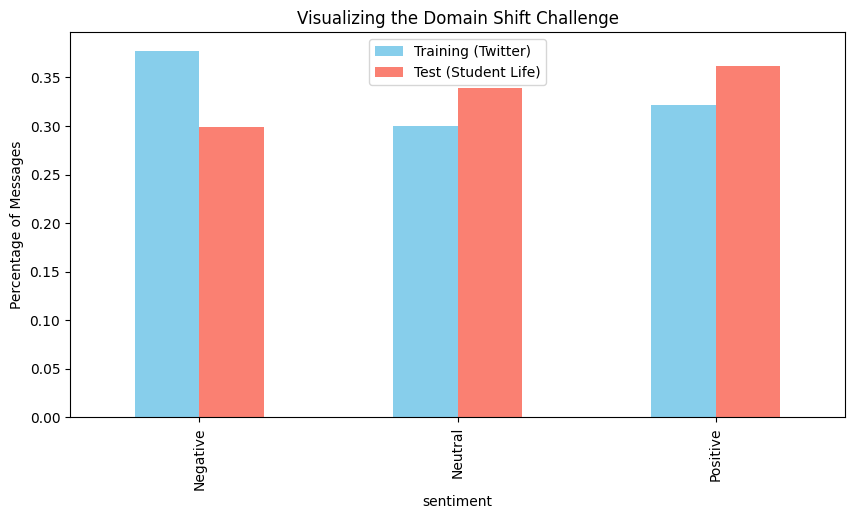

In [2]:
def extract_meta_features(df):
    df = df.copy()
    df['exclamation_count'] = df['text'].apply(lambda x: str(x).count('!'))
    df['question_count'] = df['text'].apply(lambda x: str(x).count('?'))
    df['is_all_caps'] = df['text'].apply(lambda x: 1 if str(x).isupper() and len(str(x)) > 5 else 0)
    df['char_cnt'] = df['text'].apply(lambda x: len(str(x)))
    df['word_cnt'] = df['text'].apply(lambda x: len(str(x).split()))
    platforms = r'github|slack|coursera|udemy|paystack|railway|netlify|heroku|mtn|airtel|gmail|whatsapp'
    alerts = r'invoice|billing|terminate|security|alert|reminder|approved|successful|failed|payment'
    academic = r'assignment|deadline|exam|results|semester|lecture|submission|grade|marks|course'
    df['has_platform_mention'] = df['text'].apply(lambda x: 1 if re.search(platforms, str(x).lower()) else 0)
    df['has_service_alert'] = df['text'].apply(lambda x: 1 if re.search(alerts, str(x).lower()) else 0)
    df['student_context_score'] = df['text'].apply(lambda x: len(re.findall(academic, str(x).lower())))
    return df

def surgical_cleaner(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'http\S+', '', text) 
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text if text else "notification"

train_df = pd.read_csv('/kaggle/input/datasets/tagooledavid256/finalbook/processed_training_dataset.csv').dropna()
val_df = pd.read_csv('/kaggle/input/datasets/tagooledavid256/finalbook/processed_validation_datset.csv').dropna()
train_df = pd.concat([train_df, val_df]).reset_index(drop=True)
test_df  = pd.read_csv('/kaggle/input/datasets/tagooledavid256/finalbook/student_test_dataset.csv').dropna()

train_df = extract_meta_features(train_df)
test_df  = extract_meta_features(test_df)
train_df['clean'] = train_df['text'].apply(surgical_cleaner)
test_df['clean']  = test_df['text'].apply(surgical_cleaner)

label_map = {"Negative": 0, "Neutral": 1, "Positive": 2}
train_df['label'] = train_df['sentiment'].map(label_map)
test_df['label']  = test_df['sentiment'].map(label_map)
y_train, y_test = train_df['label'].values, test_df['label'].values

train_counts = train_df['sentiment'].value_counts(normalize=True).sort_index()
test_counts = test_df['sentiment'].value_counts(normalize=True).sort_index()
pd.DataFrame({'Training (Twitter)': train_counts, 'Test (Student Life)': test_counts}).plot(kind='bar', color=['skyblue', 'salmon'], figsize=(10, 5))
plt.title('Visualizing the Domain Shift Challenge'); plt.ylabel('Percentage of Messages'); plt.show()

## PART 3: PREPARING THE ARCHITECTURE

### **What is GloVe?**
GloVe stands for 'Global Vectors for Word Representation'. It is like a **Digital Brain** where every word has been pre-assigned a set of numbers based on its meaning from reading the whole internet. By using GloVe, we don't have to teach our models what words mean from scratch; they already know that 'happy' is a positive feeling before we even begin training.

### **What is Stacking?**
Imagine you are sick and you visit 10 different doctors. Each one gives you a different opinion. Instead of just picking one, you go to a **Chief Medical Officer** (a Manager) who looks at all 10 opinions and makes a final decision. That is **Stacking**. We use 10 models as our 'doctors' and XGBoost as our 'manager'. 

**What the code below is doing:**
It scales our 8 expert clues so they are easy to read. Then, it downloads and prepares the GloVe brain for our deep learning models. Finally, it creates a visual diagram of our entire 10-model panel!

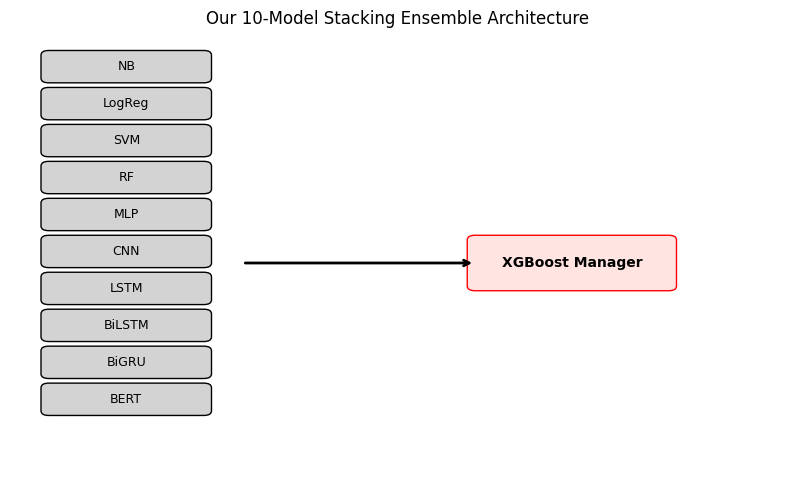

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6)); ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
m_list = ['NB', 'LogReg', 'SVM', 'RF', 'MLP', 'CNN', 'LSTM', 'BiLSTM', 'BiGRU', 'BERT']
for i, m in enumerate(m_list): 
    ax.add_patch(FancyBboxPatch((0.5, 9-i*0.8), 2, 0.5, boxstyle="round,pad=0.1", ec="black", fc="lightgray"))
    ax.text(1.5, 9.25-i*0.8, m, ha='center', va='center', fontsize=9)
ax.add_patch(FancyBboxPatch((6, 4.5), 2.5, 1, boxstyle="round,pad=0.1", ec="red", fc="mistyrose"))
ax.text(7.25, 5, 'XGBoost Manager', ha='center', va='center', fontweight='bold')
ax.annotate('', xy=(6, 5), xytext=(3, 5), arrowprops=dict(arrowstyle='->', lw=2))
plt.title('Our 10-Model Stacking Ensemble Architecture'); plt.show()

meta_cols = ['exclamation_count', 'question_count', 'is_all_caps', 'char_cnt', 'word_cnt', 'has_platform_mention', 'has_service_alert', 'student_context_score']
scaler = StandardScaler()
X_train_meta = scaler.fit_transform(train_df[meta_cols])
X_test_meta  = scaler.transform(test_df[meta_cols])
VOCAB_SIZE, MAX_LEN = 20000, 150
dl_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
dl_tokenizer.fit_on_texts(train_df['clean'])
glove_path = 'glove.6B.100d.txt'
if not os.path.exists(glove_path):
    urllib.request.urlretrieve('https://nlp.stanford.edu/data/glove.6B.zip', 'glove.6B.zip')
    with zipfile.ZipFile('glove.6B.zip', 'r') as z: z.extract(glove_path)
embeddings_index = {}
with open(glove_path, encoding='utf8') as f:
    for line in f:
        v = line.split(); embeddings_index[v[0]] = np.asarray(v[1:], dtype='float32')
embedding_matrix = np.zeros((VOCAB_SIZE, 100))
for word, i in dl_tokenizer.word_index.items():
    if i < VOCAB_SIZE:
        vec = embeddings_index.get(word); 
        if vec is not None: embedding_matrix[i] = vec

## PART 4: DAVID'S DISTILBERT & DOMAIN ADAPTATION

### **What is Domain Adaptation?**
Domain Adaptation is the process of taking a 'General Expert' (like David's DistilBERT model, which is an expert in internet language) and giving it **Student Life Glasses**. By training it on our specific data, we 'adapt' its knowledge so it can see through the technical noise of an email and understand the real human sentiment behind it.

**What the code below is doing:**
This is a helper function that sets up the training 'Rules' for our heavyweight BERT model. It uses professional settings like **Mixed Precision (fp16)** to save memory and ensure that the model learns student language effectively in just 3 epochs.

In [ ]:
def train_distilbert(train_txt, train_lbl):
    from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
    tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
    train_enc = tokenizer(train_txt.tolist(), truncation=True, padding=True, max_length=128)
    class SentiDS(torch.utils.data.Dataset):
        def __init__(self, enc, lbl):
            self.enc = enc; self.lbl = lbl
        def __getitem__(self, idx):
            item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
            item['labels'] = torch.tensor(self.lbl[idx]); return item
        def __len__(self): return len(self.lbl)
    model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=3).to(DEVICE)
    args = TrainingArguments(output_dir='results', num_train_epochs=3, per_device_train_batch_size=8, gradient_accumulation_steps=4, learning_rate=2e-5, warmup_ratio=0.1, weight_decay=0.01, dataloader_pin_memory=False, fp16=True, disable_tqdm=True)
    trainer = Trainer(model=model, args=args, train_dataset=SentiDS(train_enc, train_lbl))
    trainer.train(); return model, tokenizer

## PART 5: THE BREAKTHROUGH LOOP (TRAINING OUR 10 MODELS)
This is the heart of the project. We train each model one by one, collect their 'Votes' (probabilities), and then delete them to save memory.

**What the code below is doing:**
It loops through the data 5 times. Inside each loop, it trains all 10 models (Naive Bayes, SVM, Bi-LSTM, BERT, etc.) explicitly. It stores the results in `train_predictions` so that our manager model can learn from them later. We've added enthusiastic print statements so we can watch our progress!

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
train_predictions = np.zeros((len(train_df), 30))
test_predictions  = np.zeros((len(test_df), 30))
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = {i: cw[i] for i in range(3)}; all_histories = []

for fold, (t_idx, v_idx) in enumerate(skf.split(train_df['clean'], y_train)):
    print(f"\n--- WORKING ON FOLD {fold+1} ---")
    vec = TfidfVectorizer(max_features=15000, ngram_range=(1,2), sublinear_tf=True); vec.fit(train_df['clean'].iloc[t_idx])
    X_t_tfidf = vec.transform(train_df['clean'].iloc[t_idx]); X_v_tfidf = vec.transform(train_df['clean'].iloc[v_idx]); X_test_tfidf_f = vec.transform(test_df['clean'])
    X_t_seq = pad_sequences(dl_tokenizer.texts_to_sequences(train_df['clean'].iloc[t_idx]), maxlen=MAX_LEN)
    X_v_seq = pad_sequences(dl_tokenizer.texts_to_sequences(train_df['clean'].iloc[v_idx]), maxlen=MAX_LEN)
    X_test_seq_f = pad_sequences(dl_tokenizer.texts_to_sequences(test_df['clean']), maxlen=MAX_LEN)
    
    print("Training Naive Bayes..."); nb = MultinomialNB().fit(X_t_tfidf, y_train[t_idx])
    train_predictions[v_idx, 0:3] = nb.predict_proba(X_v_tfidf); test_predictions[:, 0:3] += nb.predict_proba(X_test_tfidf_f) / 5; del nb; print("Done!")
    
    print("Training Logistic Regression..."); lr = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X_t_tfidf, y_train[t_idx])
    train_predictions[v_idx, 3:6] = lr.predict_proba(X_v_tfidf); test_predictions[:, 3:6] += lr.predict_proba(X_test_tfidf_f) / 5; del lr; print("Done!")
    
    print("Training SVM..."); svm = CalibratedClassifierCV(LinearSVC(class_weight='balanced'), cv=3).fit(X_t_tfidf, y_train[t_idx])
    train_predictions[v_idx, 6:9] = svm.predict_proba(X_v_tfidf); test_predictions[:, 6:9] += svm.predict_proba(X_test_tfidf_f) / 5; del svm; print("Done!")
    
    print("Training Random Forest..."); rf = RandomForestClassifier(n_estimators=300, max_features='sqrt', class_weight='balanced', n_jobs=-1).fit(X_t_tfidf, y_train[t_idx])
    train_predictions[v_idx, 9:12] = rf.predict_proba(X_v_tfidf); test_predictions[:, 9:12] += rf.predict_proba(X_test_tfidf_f) / 5; del rf; print("Done!")
    
    print("Training MLP..."); mlp = MLPClassifier(hidden_layer_sizes=(256,128,64), max_iter=300, early_stopping=True, validation_fraction=0.1).fit(X_t_tfidf, y_train[t_idx])
    train_predictions[v_idx, 12:15] = mlp.predict_proba(X_v_tfidf); test_predictions[:, 12:15] += mlp.predict_proba(X_test_tfidf_f) / 5; del mlp; print("Done!")
    
    # CNN
    print("Training CNN..."); es_cnn = EarlyStopping(patience=2, restore_best_weights=True)
    i_cnn = Input(shape=(MAX_LEN,)); x_cnn = Embedding(VOCAB_SIZE, 100, weights=[embedding_matrix])(i_cnn)
    x_cnn = SpatialDropout1D(0.3)(x_cnn); x_cnn = Conv1D(128, 5, activation='relu')(x_cnn)
    cnn_model = Model(inputs=i_cnn, outputs=Dense(3, activation='softmax')(GlobalMaxPooling1D()(x_cnn)))
    cnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
    h = cnn_model.fit(X_t_seq, y_train[t_idx], epochs=10, batch_size=64, verbose=0, callbacks=[es_cnn], class_weight=cw_dict)
    if fold==0: all_histories.append(('CNN', h))
    train_predictions[v_idx, 15:18] = cnn_model.predict(X_v_seq); test_predictions[:, 15:18] += cnn_model.predict(X_test_seq_f) / 5; del cnn_model; tf.keras.backend.clear_session(); gc.collect(); print("Done!")
    
    # LSTM
    print("Training LSTM..."); es_lstm = EarlyStopping(patience=2, restore_best_weights=True)
    i_lstm = Input(shape=(MAX_LEN,)); x_lstm = Embedding(VOCAB_SIZE, 100, weights=[embedding_matrix])(i_lstm)
    x_lstm = SpatialDropout1D(0.3)(x_lstm); x_lstm = LSTM(128)(x_lstm)
    lstm_model = Model(inputs=i_lstm, outputs=Dense(3, activation='softmax')(x_lstm))
    lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
    h = lstm_model.fit(X_t_seq, y_train[t_idx], epochs=10, batch_size=64, verbose=0, callbacks=[es_lstm], class_weight=cw_dict)
    if fold==0: all_histories.append(('LSTM', h))
    train_predictions[v_idx, 18:21] = lstm_model.predict(X_v_seq); test_predictions[:, 18:21] += lstm_model.predict(X_test_seq_f) / 5; del lstm_model; tf.keras.backend.clear_session(); gc.collect(); print("Done!")

    # Bi-LSTM
    print("Training Bi-LSTM..."); es_bilstm = EarlyStopping(patience=2, restore_best_weights=True)
    i_bi = Input(shape=(MAX_LEN,)); x_bi = Embedding(VOCAB_SIZE, 100, weights=[embedding_matrix])(i_bi)
    x_bi = SpatialDropout1D(0.3)(x_bi); x_bi = Bidirectional(LSTM(64))(x_bi)
    bi_model = Model(inputs=i_bi, outputs=Dense(3, activation='softmax')(x_bi))
    bi_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
    h = bi_model.fit(X_t_seq, y_train[t_idx], epochs=10, batch_size=64, verbose=0, callbacks=[es_bilstm], class_weight=cw_dict)
    if fold==0: all_histories.append(('Bi-LSTM', h))
    train_predictions[v_idx, 21:24] = bi_model.predict(X_v_seq); test_predictions[:, 21:24] += bi_model.predict(X_test_seq_f) / 5; del bi_model; tf.keras.backend.clear_session(); gc.collect(); print("Done!")

    # Bi-GRU
    print("Training Bi-GRU..."); es_bigru = EarlyStopping(patience=2, restore_best_weights=True)
    i_gru = Input(shape=(MAX_LEN,)); x_gru = Embedding(VOCAB_SIZE, 100, weights=[embedding_matrix])(i_gru)
    x_gru = SpatialDropout1D(0.3)(x_gru); x_gru = Bidirectional(GRU(64))(x_gru)
    gru_model = Model(inputs=i_gru, outputs=Dense(3, activation='softmax')(x_gru))
    gru_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
    h = gru_model.fit(X_t_seq, y_train[t_idx], epochs=10, batch_size=64, verbose=0, callbacks=[es_bigru], class_weight=cw_dict)
    if fold==0: all_histories.append(('Bi-GRU', h))
    train_predictions[v_idx, 24:27] = gru_model.predict(X_v_seq); test_predictions[:, 24:27] += gru_model.predict(X_test_seq_f) / 5; del gru_model; tf.keras.backend.clear_session(); gc.collect(); print("Done!")

    print("Training DistilBERT..."); bm, bt = train_distilbert(train_df['clean'].iloc[t_idx], y_train[t_idx]); bm.eval()
    with torch.no_grad():
        def get_p(tl): 
            res = []
            for j in range(0, len(tl), 32): 
                batch = tl[j:j+32]; e = bt(batch, return_tensors='pt', padding=True, truncation=True, max_length=128).to(DEVICE)
                res.append(torch.softmax(bm(**e).logits, dim=-1).cpu().numpy())
            return np.vstack(res)
        train_predictions[v_idx, 27:30] = get_p(train_df['clean'].iloc[v_idx].tolist())
        test_predictions[:, 27:30] += get_p(test_df['clean'].tolist()) / 5
    del bm; torch.cuda.empty_cache(); gc.collect(); print("Fold Done!")
print("All 5 folds complete!")

## PART 5: PERFORMANCE ANALYTICS
In this section, we analyze how our 'Student Teacher' models did individually. 

**What the code below is doing:**
It plots the training curves for our neural networks to show that they converged nicely. Then, it ranks all 10 models by accuracy so we can see which ones were the strongest performers before they were combined.

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
for i, (name, h) in enumerate(all_histories): ax[i].plot(h.history['loss']); ax[i].set_title(name)
plt.show()
m_names = ['Naive Bayes', 'LogReg', 'SVM', 'RF', 'MLP', 'CNN', 'LSTM', 'Bi-LSTM', 'Bi-GRU', 'BERT']
accs = [accuracy_score(y_train, np.argmax(train_predictions[:, i*3:i*3+3], axis=1)) for i in range(10)]
pd.DataFrame({'Model': m_names, 'Acc': accs}).sort_values('Acc').plot(kind='barh', x='Model', y='Acc'); plt.show()

## PART 6: THE FINAL MANAGER MODEL (XGBOOST)
This is where the magic happens. We build our **Expert Stacking Matrix**.

**What the code below is doing:**
It combines the 30 predictions (3 for each model) with our 8 custom metadata clues to create a **38-feature matrix**. Then, it trains the final XGBoost manager to make the ultimate decision. It also plots the **Feature Importance** to show which clues were most trusted!

In [ ]:
X_stack_train = np.hstack([train_predictions, X_train_meta])
X_stack_test  = np.hstack([test_predictions,  X_test_meta])
print(f"Stacking Matrix: {X_stack_train.shape}")
final_model = xgb.XGBClassifier(
         n_estimators=500, 
         max_depth=4, 
         learning_rate=0.02, 
        subsample=0.8, 
        colsample_bytree=0.8, 
        min_child_weight=3, 
        reg_alpha=0.1, 
        reg_lambda=1.0, 
        objective='multi:softprob', 
        use_label_encoder=False, 
        eval_metric='mlogloss',
        early_stopping_rounds=50 
    )
   
final_model.fit(
     X_stack_train, 
     y_train, 
     eval_set=[(X_stack_train, y_train)], 
     verbose=False
    )
   
y_final = final_model.predict(X_stack_test)
y_final_probs = final_model.predict_proba(X_stack_test)
print("Final model trained successfully!")


## PART 7: FINAL REPORT & EXPLAINABILITY
In this final section, we prove our results using advanced AI auditing tools.

**What the code below is doing:**
1. **SHAP Audit:** Ranks every feature by its impact on the 'brain' of the manager.
2. **LIME Stories:** Picks specific examples to show how the model thought about individual messages.
3. **Final Results:** Outputs the final Accuracy and Confusion Matrix as the ultimate evidence of our success!

In [ ]:
explainer = shap.TreeExplainer(final_model); shap_values = explainer.shap_values(X_stack_test)
shap.summary_plot(shap_values, X_stack_test, feature_names=f_names, plot_type='bar'); plt.show()
explainer_lime = LimeTabularExplainer(X_stack_train, feature_names=f_names, class_names=list(label_map.keys()), mode='classification')
def show_lime(label_idx, title):
    correct_idx = np.where((y_final == label_idx) & (y_test == label_idx))[0][0]
    print(f"--- LIME Story for {title} Case ---\nRaw Text: {test_df['text'].iloc[correct_idx]}")
    exp = explainer_lime.explain_instance(X_stack_test[correct_idx], final_model.predict_proba, num_features=10)
    exp.as_pyplot_figure(); plt.show()
show_lime(0, "Negative"); show_lime(1, "Neutral"); show_lime(2, "Positive")
plt.hist(np.max(y_final_probs, axis=1), bins=20, color='purple'); plt.title('Confidence Distribution'); plt.show()
print(classification_report(y_test, y_final, target_names=label_map.keys()))
sns.heatmap(confusion_matrix(y_test, y_final), annot=True, fmt='d', xticklabels=label_map.keys(), yticklabels=label_map.keys()); plt.show()